# PROYECTO AQUALIMPIA S.A

**CARGAR LIBRERIAS**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**CARGAR DATASET**

In [4]:
df = pd.read_excel("dataset_set_A_aguas_residuales.xlsx")

**EXPLORACION INICIAL**

In [5]:
print(df.head())
print(df.info())
print(df.describe())

  fecha_registro         planta  caudal_entrada_m3_d  DBO_entrada_mg_L  \
0     2025-08-17     Planta Sur                 6562               271   
1     2025-09-07     Planta Sur                 5336               322   
2     2025-07-26   Planta Norte                 5755               318   
3     2025-10-27  Planta Centro                 6840               216   
4     2025-09-06  Planta Centro                 6803               326   

   SST_entrada_mg_L  pH_entrada  energia_aeracion_kWh  lodos_generados_kg_d  \
0               324        7.12                1261.1                 440.3   
1               230        7.01                1629.3                 561.2   
2               282        6.79                1469.2                 441.6   
3               167        7.01                1764.8                 560.0   
4               200        7.55                1409.3                 654.0   

   DBO_salida_mg_L  cumplimiento_norma  
0             40.0                   0 

**LIMPIEZA DE DATOS**

In [6]:
# Convertir fecha
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])

# Eliminar duplicados
df = df.drop_duplicates()

# Revisar nulos
print(df.isnull().sum())

fecha_registro          0
planta                  0
caudal_entrada_m3_d     0
DBO_entrada_mg_L        0
SST_entrada_mg_L        0
pH_entrada              0
energia_aeracion_kWh    0
lodos_generados_kg_d    0
DBO_salida_mg_L         0
cumplimiento_norma      0
dtype: int64


**CREAR KPI DE EFICIENCIA**

In [17]:
df['eficiencia_DBO'] = (
    (df['DBO_entrada_mg_L'] - df['DBO_salida_mg_L'])
    / df['DBO_entrada_mg_L']
) * 100

ESTADISTICAS POR PLANTA

In [8]:
resumen_plantas = df.groupby('planta')[[
    'caudal_entrada_m3_d',
    'DBO_entrada_mg_L',
    'DBO_salida_mg_L',
    'eficiencia_DBO',
    'energia_aeracion_kWh'
]].mean()

print(resumen_plantas)

               caudal_entrada_m3_d  DBO_entrada_mg_L  DBO_salida_mg_L  \
planta                                                                  
Planta Centro          5112.720000        285.186667        35.901333   
Planta Norte           5287.873239        275.845070        36.560563   
Planta Sur             4684.518519        278.796296        36.057407   

               eficiencia_DBO  energia_aeracion_kWh  
planta                                               
Planta Centro       87.513110           1260.854667  
Planta Norte        86.646784           1299.308451  
Planta Sur          87.095864           1193.775926  


**VISUALIZACION**

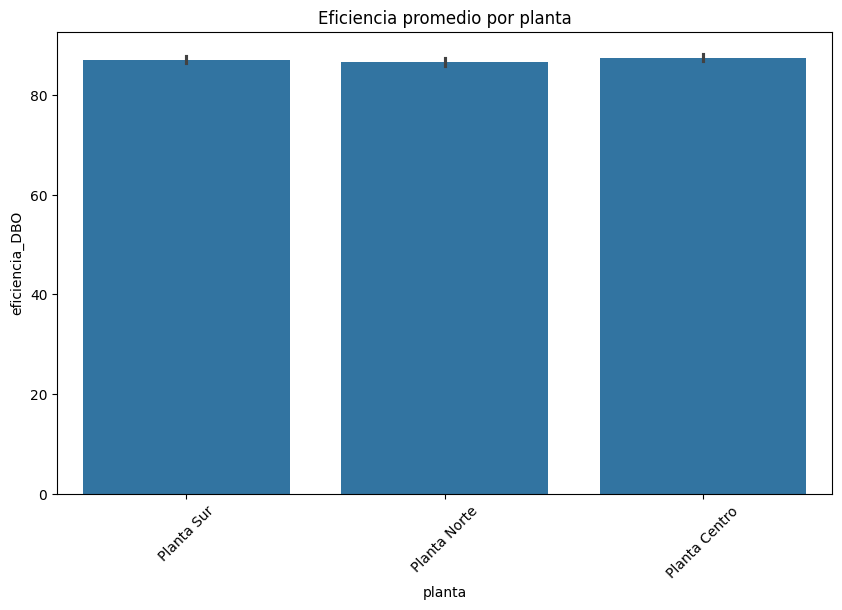

In [9]:
# Eficiencia promedio por planta
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='planta',
    y='eficiencia_DBO'
)

plt.title('Eficiencia promedio por planta')
plt.xticks(rotation=45)
plt.show()

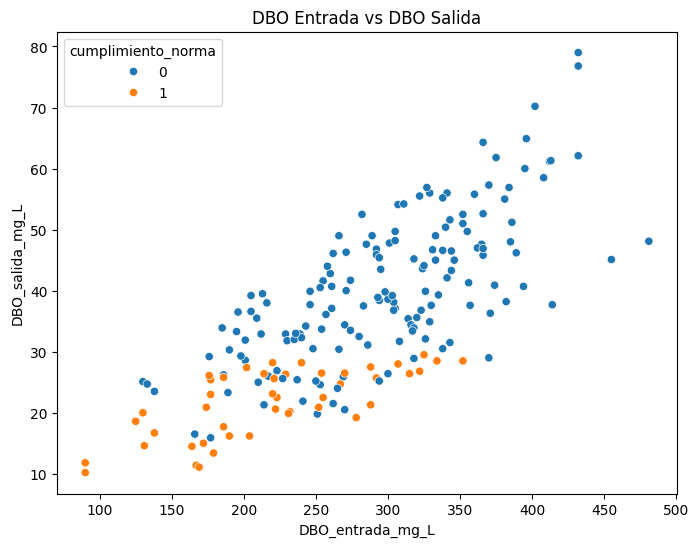

In [14]:
# Relación DBO entrada/salida
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='DBO_entrada_mg_L',
    y='DBO_salida_mg_L',
    hue='cumplimiento_norma'
)

plt.title('DBO Entrada vs DBO Salida')
plt.show()

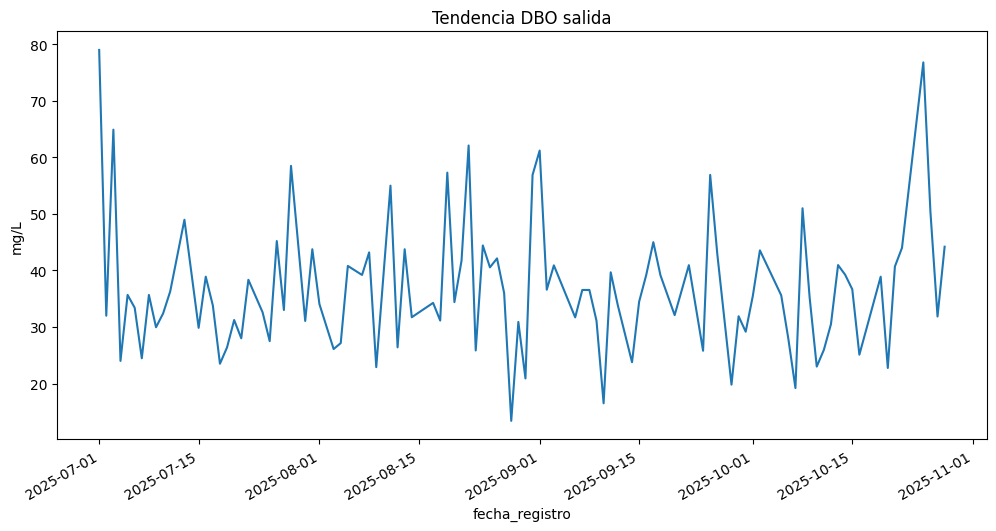

In [15]:
# Tendencia temporal
plt.figure(figsize=(12,6))

df.groupby('fecha_registro')[
    'DBO_salida_mg_L'
].mean().plot()

plt.title('Tendencia DBO salida')
plt.ylabel('mg/L')
plt.show()

**CREACION Y EXPORTACION DE ARCHIVOS**

In [16]:
# Archivo operaciones
operaciones = df[[
    'fecha_registro',
    'planta',
    'caudal_entrada_m3_d',
    'DBO_entrada_mg_L',
    'DBO_salida_mg_L',
    'energia_aeracion_kWh',
    'lodos_generados_kg_d',
    'eficiencia_DBO'
]]

operaciones.to_excel(
    'reporte_operaciones.xlsx',
    index=False
)

# Archivo gestión ambiental
ambiental = df[[
    'fecha_registro',
    'planta',
    'DBO_salida_mg_L',
    'cumplimiento_norma'
]]

ambiental.to_excel(
    'reporte_ambiental.xlsx',
    index=False
)

print("Archivos generados correctamente")

Archivos generados correctamente


**DATA SET PROCESADO**

In [18]:
df.to_excel(
    'dataset_procesado.xlsx',
    index=False
)

print("\nProceso finalizado correctamente")


Proceso finalizado correctamente
